In [1]:
from piano_string_utils import *

# Problem Statement
From *Discrete Signals and Inverse Problems*: 

Design a musical instrument to produce a 2 kHz frequency sound (e.g. wind, percussion, string). Understand the underlying physical processes and develop an analytical model to predict the resonant frequency of the instrument. Use the audio capabilities in your computer to digitize the signal and corroborate the frequency content. What is the shape Of the signal? How can you alter the frequency?

This notebook is organized as follows:
1. Instrument choice and analytical model to find instrument design parameters
2. Signal synthesis using Karplus-Strong
3. FFT to corroborate frequency content, harmonic structure. 
4. Signal shape
5. Altering frequency
6. Conclusion
7. References


## I. Inverse Problem: Designing a piano string for a desired pitch

The pitch from the note played by a key of a piano is a stretched (ideal) string under tension, with the fundamental frequency given by $$f = \frac{1}{2L}\sqrt{\frac{T}{\mu}}$$ [1]

where $ T $ is tension, $L$ is length, and $\mu$ is line density/linear mass density. I ignore the effects of things such as inharmonicity and hammer strike position and velocity for simplicity.  

To get a frequency $f_{0}$ of 2 kHz, we need a tension of $$ T = \mu(2Lf_{0})^2$$ 


and $\mu$ is given by $$ (\pi d^2)/4 \rho$$ where $\rho$ is the density of the string and $d$ is the diameter of the string.

I assume a standard steel string which has a density of 7850 kg/m $^{3}$, a diameter $d = 1\times10^{3}m$ and a length $L = .1$m, consistent with the high notes on a piano.

In [2]:
# Define parameters
L = .1 # m, consistent with high notes on piano
d = 1e-3 # m, diameter of string
rho = 7850 # kg/m^3, density of standard steel
mu = ((np.pi * d**2) / 4) * rho # linear mass density of string
print(f'mu: {mu} kg/m')

# Find tension that gives a frequency of 2000 Hz (2 kHz)
f = 2000 # Hz
T = mu * (2*L*f)**2 # N
print(f'tension: {T:.4f} N')


mu: 0.0061653755826699685 kg/m
tension: 986.4601 N


I then verify that the instrument design produces the desired frequency, concluding the analytical portion of this inverse problem; finding the desired inputs for an observed output. 

In [3]:
# Check
f = string_frequency(L, T, mu)
print(f'Calculated frequency: {f:.2f} Hz')

Calculated frequency: 2000.00 Hz


## II. Signal Synthesis with Karplus-Strong
I choose the Karplus-Strong algorithm [2] which simulates an oscillating wave by using a delay line with feedback. The algorith m can be summarized as:
1. Fill a buffer of length `N = sample_rate/f0` with noise
2. Repeatedly:
    1. output the current sample
    2. compute the new sample as the average of the two **oldest** samples in the buffer and push to the end of the buffer

This updating physically simulates damping, affecting higher frequencies faster than low ones. 

In [4]:
# Generate the signal
f0 = 2000 # Hz
sample_rate = 44100 # Hz, CD quality audio
duration = 2 # seconds, duration of time that the note is played

signal, N = karplus_strong(f0, sample_rate, duration, seed=42)

print(f"Buffer length N = {N} samples, which corresponds to a frequency of {sample_rate/N:.2f} Hz")
print(f"Actual achievable frequency = sample rate / N: {sample_rate / N:.2f} Hz")


Buffer length N = 22 samples, which corresponds to a frequency of 2004.55 Hz
Actual achievable frequency = sample rate / N: 2004.55 Hz


## III. Frequency Content and Harmonic Structure with FFT
Plotting the raw signal given by `karplus_strong` didn't give visually meaningful results. Additionally, automatic peak detection with `scipy.signal.find_peaks()` was unsuccessful, returning a single frequency of 2051 Hz. This is due to the signal's DC offset, causing `find_peaks` to miss the smaller harmonics. Removing the DC offset by subtracting the signal's mean allows for improved peak detection.

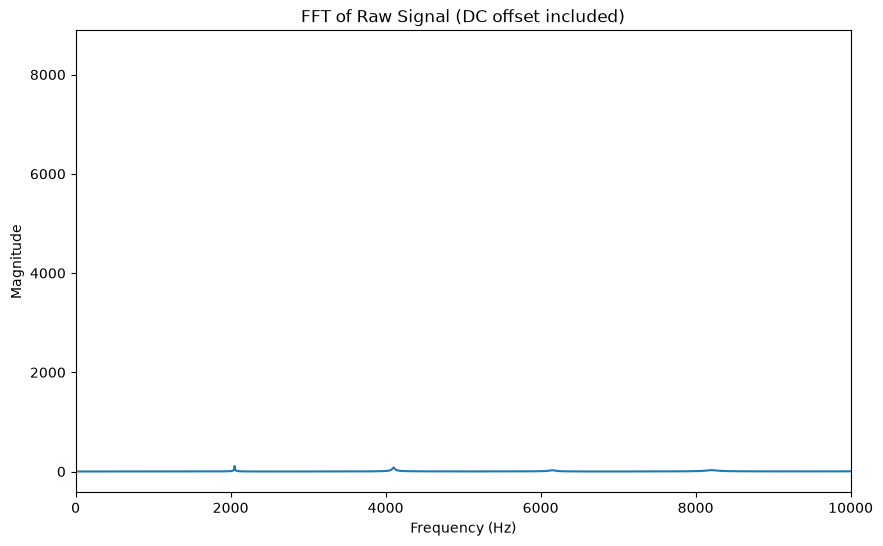

Peak frequencies found (raw): [2051.]


In [16]:
peak_freqs_raw = check_peaks(signal, sample_rate, title="FFT of Raw Signal (DC offset included)")
print(f"Peak frequencies found (raw): {np.round(peak_freqs_raw[:10], 1)}")

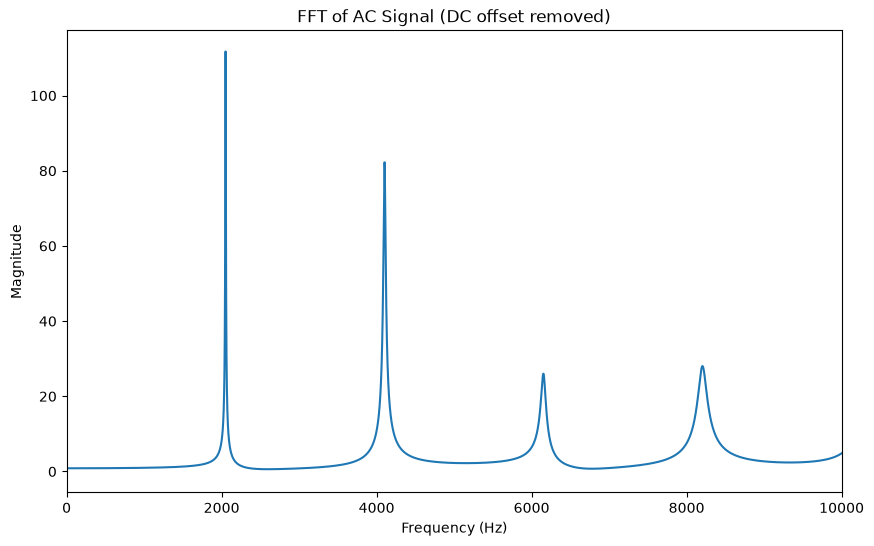

array([ 2051. ,  4102.5,  6152. ,  8204.5, 10250.5, 12299. , 14341.5,
       16411. , 20604. ])

In [17]:
signal_ac = signal - np.mean(signal) # remove DC offset
check_peaks(signal_ac, sample_rate, title="FFT of AC Signal (DC offset removed)")

Using `scipy.signal.find_peaks()`, the harmonics were identified and compared to the expected and target harmonic frequencies. The harmonics are expected to be integer multiples of the peak frequency.

In [7]:
# Check harmonics
check_harmonics(signal_ac, f0, sample_rate)

 ---------- Harmonic 1 --------------- 
                        Expected (n * measured f0) ~2051.0 Hz 
                        Target   (n * design f0)   ~2000.0 Hz 
                        Actual (FFT peak):          2051.0 Hz 
                        % Error vs measured f0:     0.00%
                        % Error vs design target:   2.55%
                        
 ---------- Harmonic 2 --------------- 
                        Expected (n * measured f0) ~4102.0 Hz 
                        Target   (n * design f0)   ~4000.0 Hz 
                        Actual (FFT peak):          4102.5 Hz 
                        % Error vs measured f0:     0.01%
                        % Error vs design target:   2.56%
                        
 ---------- Harmonic 3 --------------- 
                        Expected (n * measured f0) ~6153.0 Hz 
                        Target   (n * design f0)   ~6000.0 Hz 
                        Actual (FFT peak):          6152.0 Hz 
                        % Error

The fundamental frequency was 2.55% higher than the target frequency, likely attributable to the integer correction on `N`. Subsequent harmonics were found to be near integer multiples of the measured fundamental `f0` as desired. This confirms that the synthesized signal's frequency content is consistent with the analytical model and expected harmonic structure of an ideal string.

## IV. Signal Shape


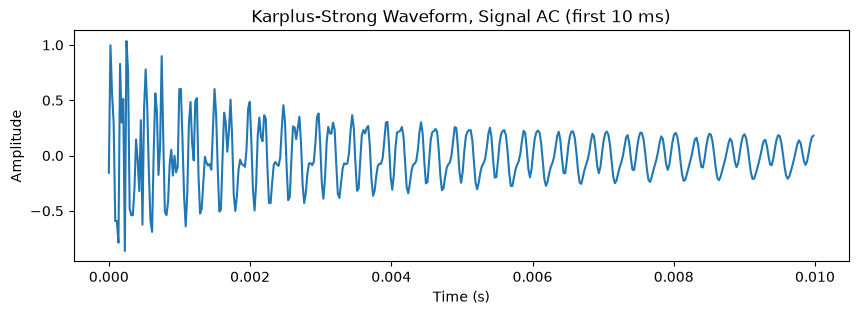

In [8]:
# Step 4: Signal shape
plot_signal_shape(signal_ac, sample_rate)

Discussion on signal shape: 

To find the note name, I use the equation: 

$$ f_0 = f_1 (\sqrt[12]{2})^n $$

where $f_1 = A4 = 440$ Hz. Solving for $n$, the number of semitones away from A4:

$$ n = 12 \log_2(\frac{f_0}{f_1}) $$

Since $f_0$ (the measured fundamental) will rarely land exactly on a semitone, $n$ is rounded 
to the nearest integer to identify the nearest note name, with the residual fractional part 
indicating the tuning deviation in cents (100 cents = 1 semitone) [3].

Then, the MIDI note number (a system used to numerically identify musical notes) is found. A4 is note number 69 by convention. 

The desired note from a frequency of 2kHz is B6, about +21.3 cents off, while the generated note is C7, about -35.1 cents off. Despite being on different keys, the notes differ only by a few cents, and thus are relavitely close together. 

In [10]:
freqs_pos, mags_pos = get_fft(signal_ac, sample_rate)
peak_freq = find_signal_peaks(freqs_pos, mags_pos)[0]

note_target, cents_target = freq_to_note(f0)
note_measured, cents_measured = freq_to_note(peak_freq)

print(f"Target note: {note_target}, {cents_target:+.1f} cents off")
print(f"Generated note: {note_measured}, {cents_measured:+.1f} cents off")

Target note: B6, +21.3 cents off
Generated note: C7, -35.1 cents off


## Testing the sound
Finally, I tested the simulated sound against a "pure" tone of frequency 2kHz. The pure tone is generated using a sine wave. 

The difference in the sounds is striking; the string-like sound of the generated tone is immediately apparent in contrast to the flat, alarm-like tone of the pure sine wave. This difference demonstrates the effectiveness of the Karplus-Strong algorithm in the harmonic content, decay envelope, and attack transient in producing a string-like sound. 

In [12]:
tone_f0 = pure_tone(f0, sample_rate, duration=1.0)

print("Pure sine tone at exact f0 (2000 Hz):")
test_sound(tone_f0, sample_rate)

print("Karplus-Strong generated tone (~2051 Hz):")
test_sound(signal_ac, sample_rate)

Pure sine tone at exact f0 (2000 Hz):
Karplus-Strong generated tone (~2051 Hz):


## Altering the sound



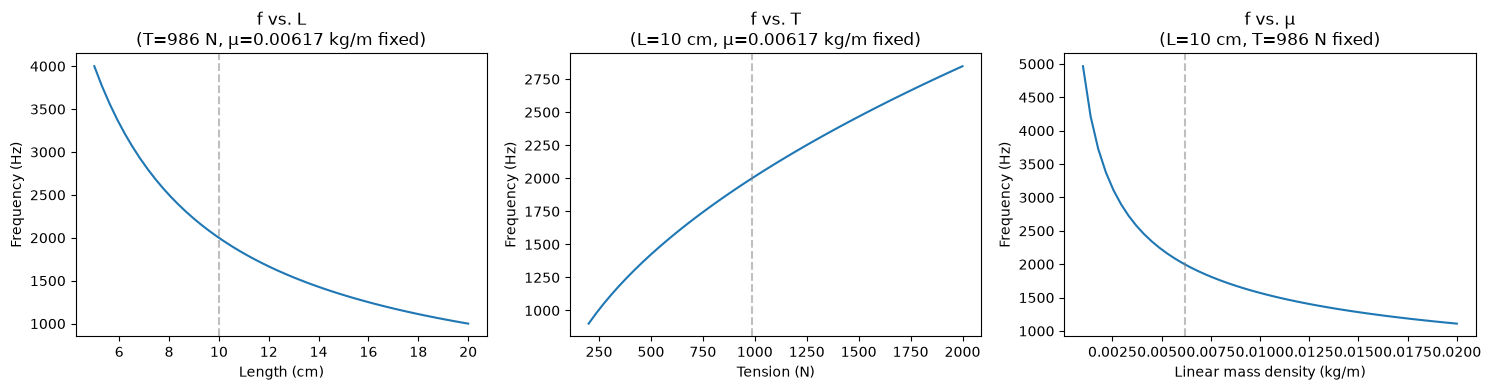

In [13]:
# Baseline values (from earlier)
L_base = 0.1        # m
T_base = 986.46     # N
mu_base = 0.0061654 # kg/m

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Vary L, hold T and mu fixed ---
L_range = np.linspace(0.05, 0.2, 50)
f_vs_L = string_frequency(L_range, T_base, mu_base)
axes[0].plot(L_range * 100, f_vs_L)  # convert to cm for readability
axes[0].axvline(L_base * 100, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel("Length (cm)")
axes[0].set_ylabel("Frequency (Hz)")
axes[0].set_title(f"f vs. L\n(T={T_base:.0f} N, μ={mu_base:.5f} kg/m fixed)")

# --- Vary T, hold L and mu fixed ---
T_range = np.linspace(200, 2000, 50)
f_vs_T = string_frequency(L_base, T_range, mu_base)
axes[1].plot(T_range, f_vs_T)
axes[1].axvline(T_base, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel("Tension (N)")
axes[1].set_ylabel("Frequency (Hz)")
axes[1].set_title(f"f vs. T\n(L={L_base*100:.0f} cm, μ={mu_base:.5f} kg/m fixed)")

# --- Vary mu, hold L and T fixed ---
mu_range = np.linspace(0.001, 0.02, 50)
f_vs_mu = string_frequency(L_base, T_base, mu_range)
axes[2].plot(mu_range, f_vs_mu)
axes[2].axvline(mu_base, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel("Linear mass density (kg/m)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title(f"f vs. μ\n(L={L_base*100:.0f} cm, T={T_base:.0f} N fixed)")

plt.tight_layout()
plt.show()

In [15]:
# Choose a few altered parameter sets to demonstrate audible pitch change
variants = [
    {"label": "Baseline (L=10cm)",     "L": 0.10, "T": T_base, "mu": mu_base},
    {"label": "Shorter string (L=7cm)", "L": 0.07, "T": T_base, "mu": mu_base},
    {"label": "Longer string (L=15cm)", "L": 0.15, "T": T_base, "mu": mu_base},
    {"label": "Higher tension (T=1500N)", "L": L_base, "T": 1500, "mu": mu_base},
    {"label": "Thicker string (μ x2)",  "L": L_base, "T": T_base, "mu": mu_base * 2},
]

for v in variants:
    f_variant = string_frequency(v["L"], v["T"], v["mu"])
    note, cents = freq_to_note(f_variant)
    
    print(f"{v['label']}: L={v['L']*100:.1f}cm, T={v['T']:.0f}N, "
          f"μ={v['mu']:.5f}kg/m -> f = {f_variant:.1f} Hz ({note}, {cents:+.1f} cents)")
    
    signal_variant, N_variant = karplus_strong(f_variant, sample_rate, duration=1.0, seed=42)
    signal_variant_ac = signal_variant - np.mean(signal_variant)
    
    test_sound(signal_variant_ac, sample_rate)

Baseline (L=10cm): L=10.0cm, T=986N, μ=0.00617kg/m -> f = 2000.0 Hz (B6, +21.3 cents)
Shorter string (L=7cm): L=7.0cm, T=986N, μ=0.00617kg/m -> f = 2857.1 Hz (F7, +38.8 cents)
Longer string (L=15cm): L=15.0cm, T=986N, μ=0.00617kg/m -> f = 1333.3 Hz (E6, +19.4 cents)
Higher tension (T=1500N): L=10.0cm, T=1500N, μ=0.00617kg/m -> f = 2466.2 Hz (D#7, -15.9 cents)
Thicker string (μ x2): L=10.0cm, T=986N, μ=0.01233kg/m -> f = 1414.2 Hz (F6, +21.3 cents)


## References


- [1]
- [2]
- [3]